In [23]:
import matplotlib.pyplot as plt
import matplotlib as mp
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio

from collections import Counter
# Hierarchical clustering and dendrograms
from scipy.cluster.hierarchy import dendrogram, linkage

# Advanced plotting and heatmaps
from PyComplexHeatmap import *

# Statistical annotation
from statannotations.Annotator import Annotator
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
from sklearn import preprocessing
plt.style.use('/cndd2/jchien/project/Dracheva_Development/script/mplstyle_pec')

BOXPROPS = {
    'boxprops':{'edgecolor':'k','linewidth':0.5},
    'medianprops':{'color':'k','linewidth':0.5},
    'whiskerprops':{'color':'k','linewidth':0.5},
    'capprops':{'color':'k','linewidth':0.5}
}
%matplotlib inline

In [2]:
metafile = pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/PEC_donor_LIMS.csv',index_col = 0)

In [ ]:
# PairdGroup_P = {}
# for celltype in ['GABA','GLU']:
#     sig_genes_exp = pd.read_csv(f'{celltype}_DE_pvalue_table.csv',index_col=[0])
#     # sig_genes_exp[ sig_genes_exp < 0] = -1
#     # sig_genes_exp[ sig_genes_exp > 0] = 1
#     PairdGroup_P[celltype] = sig_genes_exp
#     print(f'{celltype} has {sig_genes_exp.shape[0]} genes')

In [ ]:
# PairdGroup_FC = {}
# for celltype in ['GABA','GLU']:
#     sig_genes_exp = pd.read_csv(f'{celltype}_FC.csv',index_col=[0])
#     PairdGroup_FC[celltype] = sig_genes_exp
#     print(f'{celltype} has {sig_genes_exp.shape[0]} genes')

In [ ]:
# all_genes_P = pd.concat( list( PairdGroup_P.values()), keys=list(PairdGroup_P.keys()))
# all_genes_P.index.names = ['cell_type', 'gene']
# all_genes_FC = pd.concat( list( PairdGroup_FC.values()), keys=list(PairdGroup_P.keys()))
# all_genes_FC.index.names = ['cell_type', 'gene']
# all_genes_FC[all_genes_P >= 0.05] = 0


In [8]:
all_results = pd.read_csv('Dream_all_results.csv',sep= ',')
all_logFC = all_results.pivot_table(index=['celltype', 'geneID'], columns='comp', values='logFC')
all_P = all_results.pivot_table(index=['celltype', 'geneID'], columns='comp', values='adj.P.Val')
all_logFC = all_logFC.where(all_P < 0.05).fillna(0)
all_logFC = all_logFC.loc[~(all_logFC == 0).all(axis=1)]
all_logFC = all_logFC[['infancy-earlychildhood','infancy-latechildhood','infancy-adolescence','infancy-adulthood','infancy-lateadulthood','earlychildhood-latechildhood',
           'earlychildhood-adolescence','earlychildhood-adulthood','earlychildhood-lateadulthood','latechildhood-adolescence',
           'latechildhood-adulthood','latechildhood-lateadulthood','adolescence-adulthood','adolescence-lateadulthood','adulthood-lateadulthood']]

In [53]:
len(all_results[(all_results['adj.P.Val'] < 0.05)]['geneID'].unique())

8109

In [6]:
def same_sign(row):
    # Filter out zero elements and get the sign of each remaining element
    signs = row[row != 0].apply(np.sign)
    # Check if all non-zero elements have the same sign
    return signs.nunique() == 1 if not signs.empty else True

In [7]:
def Trend_detection(row):
    signs = row[row != 0].apply(np.sign)

    if all(signs > 0) > 0:
        if abs(row['infancy-earlychildhood']) > abs(row['earlychildhood-lateadulthood']):
            return 0
        else:
            return 1
    else:
        if abs(row['infancy-earlychildhood']) > abs(row['earlychildhood-lateadulthood']):
            return 2
        else:
            return 3

In [8]:
all_genes_FC_monotones  = all_logFC.loc[all_logFC.apply(same_sign, axis=1)]

In [9]:
all_genes_FC_monotones['trend'] = all_genes_FC_monotones.apply(Trend_detection, axis=1)

/tmp/ipykernel_1370394/3167438717.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_genes_FC_monotones['trend'] = all_genes_FC_monotones.apply(Trend_detection, axis=1)


In [10]:
all_logFC['trend'] = [all_genes_FC_monotones.loc[i, 'trend'] if i in all_genes_FC_monotones.index else 4 for i in all_logFC.index]
all_logFC.head()

comp                         infancy-earlychildhood  infancy-latechildhood  \
celltype geneID                                                              
GABA     ENSG00000000419.13                     0.0                    0.0   
         ENSG00000001036.14                     0.0                    0.0   
         ENSG00000001167.14                     0.0                    0.0   
         ENSG00000001461.17                     0.0                    0.0   
         ENSG00000001497.18                     0.0                    0.0   

comp                         infancy-adolescence  infancy-adulthood  \
celltype geneID                                                       
GABA     ENSG00000000419.13                  0.0          -0.675948   
         ENSG00000001036.14                  0.0           0.000000   
         ENSG00000001167.14                  0.0           0.000000   
         ENSG00000001461.17                  0.0           0.000000   
         ENSG00000001497.18                  0.0           0.000000   

comp                         infancy-lateadulthood  \
celltype geneID                                      
GABA     ENSG00000000419.13               0.000000   
         ENSG00000001036.14              -0.640894   
         ENSG00000001167.14               0.000000   
         ENSG00000001461.17               0.000000   
         ENSG00000001497.18               0.000000   

comp                         earlychildhood-latechildhood  \
celltype geneID                                             
GABA     ENSG00000000419.13                           0.0   
         ENSG00000001036.14                           0.0   
         ENSG00000001167.14                           0.0   
         ENSG00000001461.17                           0.0   
         ENSG00000001497.18                           0.0   

comp                         earlychildhood-adolescence  \
celltype geneID                                           
GABA     ENSG00000000419.13                    0.000000   
         ENSG00000001036.14                    0.000000   
         ENSG00000001167.14                    0.000000   
         ENSG00000001461.17                    0.500255   
         ENSG00000001497.18                   -0.529554   

comp                         earlychildhood-adulthood  \
celltype geneID                                         
GABA     ENSG00000000419.13                  0.000000   
         ENSG00000001036.14                  0.000000   
         ENSG00000001167.14                  0.000000   
         ENSG00000001461.17                  0.522957   
         ENSG00000001497.18                  0.000000   

comp                         earlychildhood-lateadulthood  \
celltype geneID                                             
GABA     ENSG00000000419.13                      0.000000   
         ENSG00000001036.14                      0.000000   
         ENSG00000001167.14                     -0.376079   
         ENSG00000001461.17                      0.754494   
         ENSG00000001497.18                     -0.460881   

comp                         latechildhood-adolescence  \
celltype geneID                                          
GABA     ENSG00000000419.13                        0.0   
         ENSG00000001036.14                        0.0   
         ENSG00000001167.14                        0.0   
         ENSG00000001461.17                        0.0   
         ENSG00000001497.18                        0.0   

comp                         latechildhood-adulthood  \
celltype geneID                                        
GABA     ENSG00000000419.13                      0.0   
         ENSG00000001036.14                      0.0   
         ENSG00000001167.14                      0.0   
         ENSG00000001461.17                      0.0   
         ENSG00000001497.18                      0.0   

comp                         latechildhood-lateadulthood  \
celltype geneID                               

Processing group: 0
Processing group: 1
Processing group: 2
Processing group: 3
Processing group: 4
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Plotting legends..
Estimated legend width: 23.6375 mm


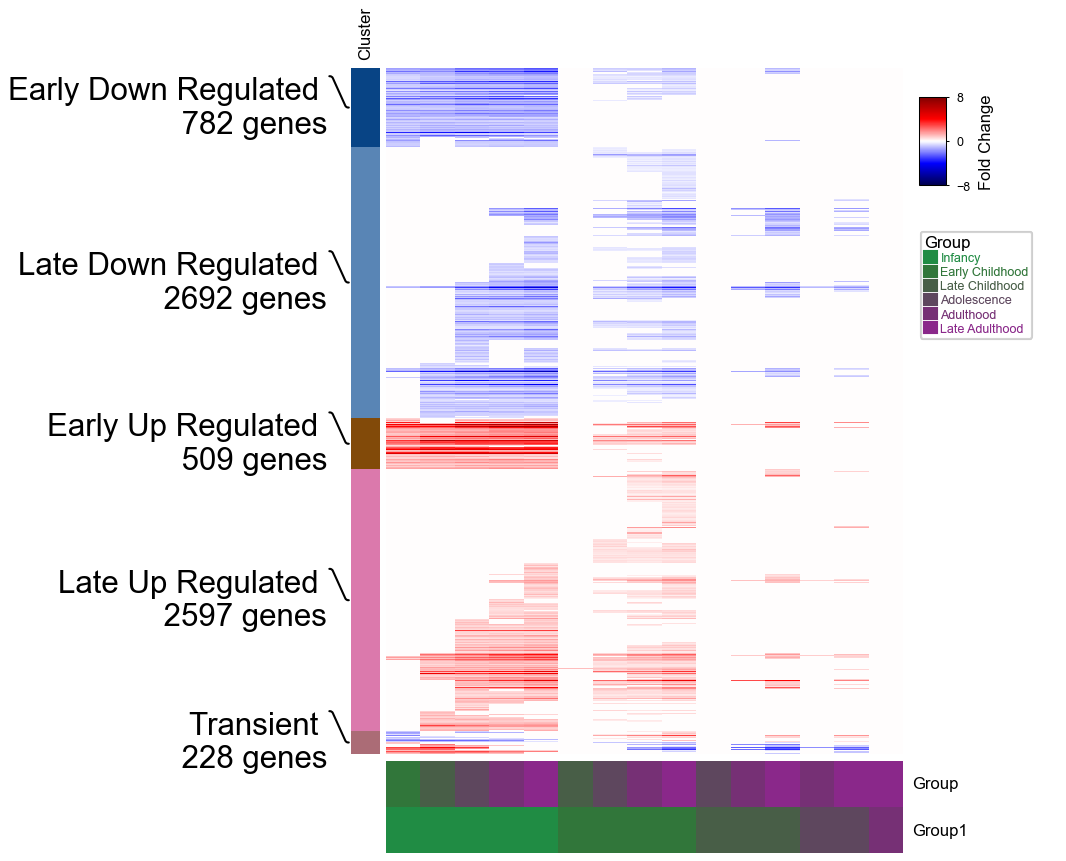

Processing group: 0
Processing group: 1
Processing group: 2
Processing group: 3
Processing group: 4
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Plotting legends..
Estimated legend width: 23.6375 mm


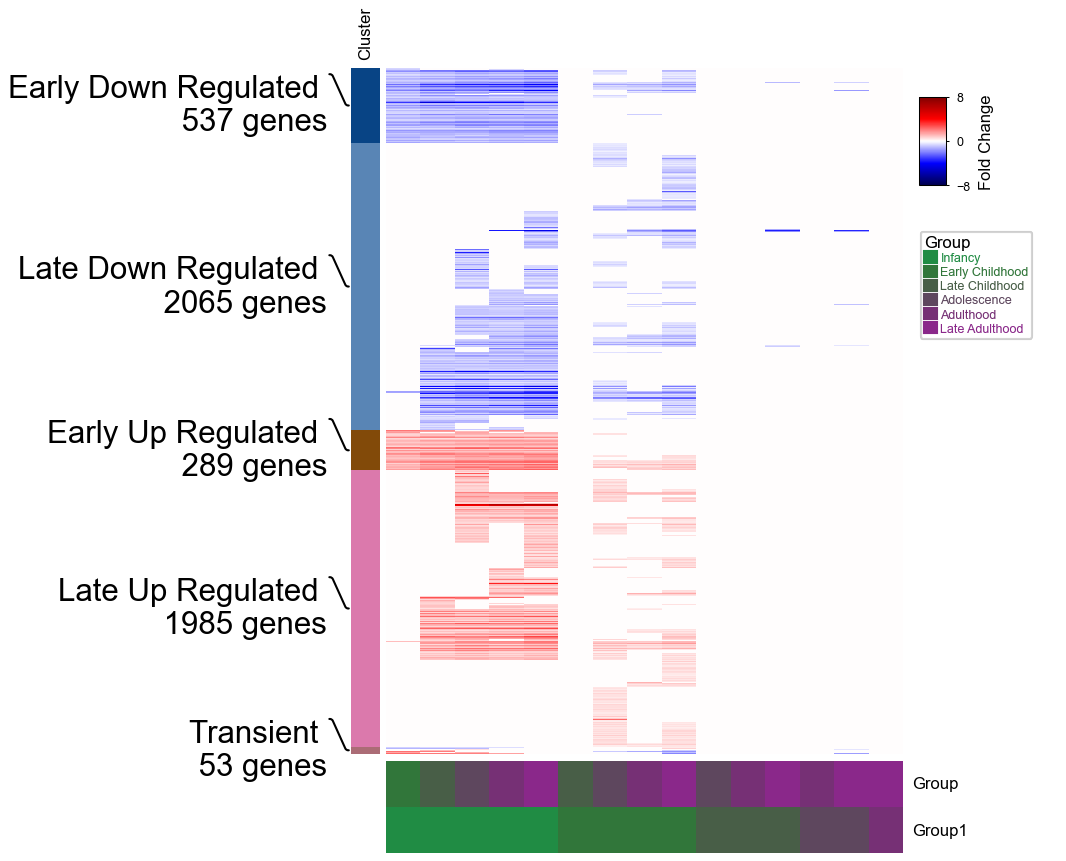

In [22]:
for celltype in ['GLU','GABA']:
    plt.figure(figsize=(5, 6))
    reordered_indices  = []
    num_gene = 0 
    #for group in ['Early Down Regulated','Late Down Regulated','Early Up Regulated','Late Up Regulated', 'Trans']:
    for group in [0,1,2,3,4]:
        print(f"Processing group: {group}")
        # Subset the DataFrame based on the group, preserving the original index
        group_df = all_logFC.loc[celltype][all_logFC.loc[celltype]['trend'] == group].drop('trend', axis=1)
        group_df.fillna(0, inplace=True)
        if group_df.shape[0] < 2:
            reordered_indices.extend(group_df.index.values)
            continue
        # Perform clustering to determine the row order
        g = sns.clustermap(group_df, method='ward', metric='correlation',
                    col_cluster=False, row_cluster=True,  # Disable clustering
                    row_linkage=None, col_linkage=None,  # No linkage
                    xticklabels=False, yticklabels=False)
        plt.close()  # We don't need to display this plot

        # Extract the reordered indices from the clustering
        reordered_indices.extend(group_df.index[g.dendrogram_row.reordered_ind].values)


    all_genes_FC_sorted = all_logFC.loc[celltype].loc[reordered_indices]
    all_genes_FC_sorted['num_genes'] = [Counter(all_genes_FC_sorted['trend'])[i] for i in all_genes_FC_sorted['trend'] ]
    all_genes_FC_sorted.columns  = ['Infancy-Early Childhood','Infancy-Late Childhood','Infancy-Adolescence','Infancy-Adulthood','Infancy-Late Adulthood',
                    'Early Childhood-Late Childhood','Early Childhood-Adolescence','Early Childhood-Adulthood','Early Childhood-Late Adulthood',
                    'Late Childhood-Adolescence','Late Childhood-Adulthood','Late Childhood-Late Adulthood',
                    'Adolescence-Adulthood','Adolescence-Late Adulthood',
                    'Adulthood-Late Adulthood','trend','num_genes']

    
    all_genes_FC_sorted_heatmap = all_genes_FC_sorted.drop(['trend','num_genes'],axis=1)

    


    gene_cluster_name = ['Early Down Regulated', 'Late Down Regulated', 'Early Up Regulated', 'Late Up Regulated', 'Transient']
    all_genes_FC_sorted['Trend'] = [gene_cluster_name[i] for i in all_genes_FC_sorted['trend']]
    all_genes_FC_sorted['Trend']  = [ i[0] + ' \n ' + str(i[1]) + ' genes' for i in zip(all_genes_FC_sorted['Trend'],all_genes_FC_sorted['num_genes'])]

    split_columns = [name.split('-') for name in all_genes_FC_sorted_heatmap.columns]
    group1 = [item[0] if len(item) > 0 else None for item in split_columns]
    group2 = [item[1] if len(item) > 1 else None for item in split_columns]

    # Create a new DataFrame

    ann_labels = []
    for i in Counter(all_genes_FC_sorted['Trend'].astype(str)).keys():
        ann_labels.append(i)
    new_f = pd.DataFrame({'Group1': group1, 'Group2': group2}, index=all_genes_FC_sorted_heatmap.columns)



    row_ha1 = HeatmapAnnotation(                            
                                GeneCluster = anno_label(all_genes_FC_sorted['Trend'].astype(str),merge=True,fontsize = 15, rotation=0,legend=False,
                                colors={ann_labels[0]:'#000000',
                                         ann_labels[1]:'#000000',
                                          ann_labels[2]:'#000000',
                                          ann_labels[3]:'#000000',
                                          ann_labels[4]:'#000000'}
                                          ),

                                Cluster=anno_simple(all_genes_FC_sorted['Trend'].astype(str),add_text=False,height = 5,legend=False,
                                                    colors={ann_labels[0]:'#084485',
                                                            ann_labels[1]:'#5985b5',
                                                            ann_labels[2]:'#824a09',
                                                            ann_labels[3]:'#db79ac',
                                                            ann_labels[4]:'#ab6c76'}                                                      
                                                    ),
                                #label_kws = None,#{'size': 8,'rotation':0,'horizontalalignment':'right'},
                                label_side='top',
                                axis=0,verbose=0)
    col_ha1 = HeatmapAnnotation(
                                Group = anno_simple(new_f.Group2,add_text=False,height = 7,                                                    
                                                    colors={'Infancy':'#208C44', 'Early Childhood':'#31763A', 'Late Childhood':'#485E47',
                                                            'Adolescence':'#5E475E', 'Adulthood':'#763075','Late Adulthood':'#8A288A'},legend=True),                                
                                Group1 = anno_simple(new_f.Group1,add_text=False,height = 7,
                                                     text_kws={'rotation':0,'fontsize':10,'color': 'white'},
                                                    colors={'Infancy':'#208C44','Early Childhood':'#31763A','Late Childhood':'#485E47',
                                                                                                    'Adolescence':'#5E475E','Adulthood':'#763075','Late Adulthood':'#8A288A'},legend=False),
                                #label_kws = {'size' :6,'rotation':-60,'horizontalalignment':'left'},
                                #label_side='bottom',
                                axis=1,verbose=0)




    cm = ClusterMapPlotter(

                        data=-all_genes_FC_sorted_heatmap,
                        left_annotation = row_ha1,
                        bottom_annotation=col_ha1,
                        center = 0,
                        col_cluster =  False,
                        vmin = -8,
                        vmax = 8,
                        cmap = 'seismic',
                        #row_names_side='left',
                        row_cluster= False,
                        row_dendrogram=False,
                        col_dendrogram=False,
                        show_rownames=False,
                        show_colnames=False,
                        label = 'Fold Change',
                        #xticklabels_kws={'labelrotation':-60,'labelcolor':'blue','size':}
                        verbose=2,
                        #rasterize = True,
                        )
    #plt.savefig(f'{celltype}_Gene_Cluster.pdf',dpi = 200)
    plt.show()